<a href="https://colab.research.google.com/github/marcinwolter/MachineLearning-KISD-2026/blob/main/lecture6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>




#**<font color = "red">Introduction to machine learning</font>**

**Lecture 6**


#**<font color = "green">Generative Neural Networks</font>**

*8 April 2026*


---

*Marcin Wolter, IFJ PAN*

*e-mail: marcin.wolter@ifj.edu.pl*


---
</center>

#<font color='green'>**Program for today:**


* ###  <font color='red'>Generative Adversarial Networks (GANs): how to generate artificial data?
* ###  <font color='red'>Stable Diffusion algorithm

<br>


**As always all slides are here:**

*https://github.com/marcinwolter/MachineLearning-KISD-2026*

<br>






---



---



---



# <font color = green> **Generative Adversarial Nets (GANs)**

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/MachineLearning2020_100.png' width=650px>




**Generative Adversarial Nets \(GANs\)** were introduced by Ian Goodfellow and others in 2014\. Yann LeCun called **adversarial training** “the most interesting idea in the last 10 years in ML\.” </span><br>  <span style="color:#000000">[https://arxiv\.org/abs/1406\.2661](https://arxiv.org/abs/1406.2661)</span>

<span style="color:#000000">**GANs** can learn to mimic any distribution of data\. They can be taught to create worlds similar to our own in any domain: images\, music\, speech\, prose\. They are robot artists\!</span>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/MachineLearning2020_101.png' width=450px>



<span style="color:#800000"> __Next Rembrandt project 2016__ </span>

<span style="color:#000000">Create automatically a new Rembrandt portrait based on a collection of Rembrandt works:</span>

<span style="color:#000000">[https://www\.nextrembrandt\.com/](https://www.nextrembrandt.com/)</span>  <span style="color:#000000"> </span>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/MachineLearning2020_102.png' width=450px>

 **“The Next Rembrandt”**, a 2016 project funded by a variety of corporations led by financial services company ING, used AI to generate a new Rembrandt-like painting that was 3D printed and displayed.

---

<img src='https://upload.wikimedia.org/wikipedia/commons/thumb/c/c1/Edmond_de_Belamy.png/1920px-Edmond_de_Belamy.png' width=450px>

In 2018, the Obvious artist collective created **“Edmond de Belamy”**, a portrait that evokes what might be called an impressionistic Rembrandt, and which became the first AI painting sold at auction by Christie’s.


#<font color='green'>**How does GAN work?**
###**Blind forger and detective**

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/MachineLearning2020_104.png' width=450px>

* The forger has never seen Mona Lisa\, but gets the judgments of detective and tries to fool him \(i\.e\. paint something that looks like Mona Lisa\)\.

* <span style="color:#000000">They both \(forger and detective\) have to train in parallel \(important\)\, since if detective is to clever the forger will never paint anything acceptable\.</span>

---





#<font color='green'>**Generator and discriminator**

* <span style="color:#000000"> __Discriminative algorithms__ </span>  <span style="color:#000000"> \- classify input data; given the features\, they predict a label or category to which that data belongs \(</span>  <span style="color:#000000"> _signal_ </span>  <span style="color:#000000"> or </span>  <span style="color:#000000"> _background_ </span>  <span style="color:#000000">\)</span>
* <span style="color:#000000"> __Generative algorithms__ </span>  <span style="color:#000000">– do the opposite\, assuming the event is a </span>  <span style="color:#000000"> _signal_ </span>  <span style="color:#000000">\, how likely are these features? </span>
* <span style="color:#000000">A way to distinguish discriminative from generative algorithms is:</span>
  * <span style="color:#000000"> __Discriminative models__ </span>  <span style="color:#000000"> learn the boundary between classes</span>
  * <span style="color:#000000"> __Generative models__ </span>  <span style="color:#000000"> model the distribution of individual classes</span>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/MachineLearning2020_103.png' width=350px>


#**How the GAN is built?**

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/Zrzut%20ekranu%202022-04-22%20144540.png' width=650px>

* **Generator** gets a random vector as an input and transforms it into an image.<br>
In **Generative Models**
we try to learn the underlying the distribution
from which our dataset comes from.
* **Discriminator** compares the generated data to the real data.
* **Adversarial Training:**
GANS are made up of two competing networks (adversaries - generator and discriminator)
that are trying beat each other.



<img src='https://www.researchgate.net/profile/Bhaskar_Ghosh3/publication/344544069/figure/fig1/AS:944366453542923@1602165916976/Generative-Adversarial-Network-Architecture-2.jpg' width=650px>

#**Example generator code**

```python
    def __generator(self):
        """ Declare generator """

        model = Sequential()
        model.add(Dense(256, input_shape=(100,)))
        model.add(LeakyReLU(alpha=0.2))  
        model.add(BatchNormalization(momentum=0.8))
        model.add(Dense(512))
        model.add(LeakyReLU(alpha=0.2))
        model.add(BatchNormalization(momentum=0.8))
        model.add(Dense(1024))
        model.add(LeakyReLU(alpha=0.2))
        model.add(BatchNormalization(momentum=0.8))
        model.add(Dense(self.width  * self.height * self.channels, activation='tanh'))
        model.add(Reshape((self.width, self.height, self.channels)))

        return model
```



#**Example discriminator code**

```python
    def __discriminator(self):
        """ Declare discriminator """

        model = Sequential()
        model.add(Flatten(input_shape=self.shape))
        model.add(Dense((self.width * self.height * self.channels), input_shape=self.shape))
        model.add(LeakyReLU(alpha=0.2))
        model.add(Dense(np.int64((self.width * self.height * self.channels)/2)))
        model.add(LeakyReLU(alpha=0.2))
        model.add(Dense(1, activation='sigmoid'))
        model.summary()

        return model
```

#**Why LeakyReLu activation function?**



| <img src='https://cdn-media-1.freecodecamp.org/images/2Gt22y40ECfoeueVhbdJxlSxN56ANsdz1Upt' width=250px>  	|   <img src='https://cdn-media-1.freecodecamp.org/images/jnloudDblWrrXgjam9wLcJSIXhCkQsb4WIhz' width=250px>	|
|:-:	|:-:	|
|  ReLu 	|  LeakyReLu 	|



A regular ReLU function works by truncating negative values to 0. This has the effect of blocking the gradients to flow through the network. Instead of the function being zero, leaky ReLUs allow a small negative value to pass through. That is, the function computes the greatest value between the features and a small factor.

Leaky ReLUs represent an attempt to solve the dying ReLU problem. This situation occurs when the neurons get stuck in a state in which ReLU units always output 0s for all inputs. For these cases, the gradients are completely shut to flow back through the network.

This is especially important for GANs since the only way the generator has to learn is by receiving the gradients from the discriminator.

#**How to train a GAN?**

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/Zrzut%20ekranu%202022-04-22%20144714.png' width=650px>

We have to train discriminator to distinguish real and fake data...

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/Zrzut%20ekranu%202022-04-22%20145742.png'  width=650px>

... then train the generator to beat the discriminator.

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/Zrzut%20ekranu%202022-04-22%20145842.png' width=650px>

We have to repeat this cycle many times to train both discriminator and generator in parallel.


#**Losses**

* Discriminator receives images from both the training set and the generator. Each mini-batch we get logits from the discriminator. These are the unscaled values from the model.

* In mini-batches the discriminator receives fake and real images.
Because generator and discriminator train at the same time, GANs also need two optimizers. Each one for minimizing the discriminator and generator’s loss functions respectively.

* We want the discriminator to output probabilities close to 1 for real images and near 0 for fake images. To do that, the discriminator needs two losses. Therefore, the total loss for the discriminator is the sum of these two partial losses. **One for maximizing the probabilities for the real images and another for minimizing the probability of fake images.**




<span style="color:#800000"> __GANs example – hand\-written digits__ </span>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/MachineLearning2020_105.png' width=650px>

<span style="color:#000000"> __Training set__ </span>  <span style="color:#000000"> – MNIST: hand\-written digits supplied by US post\.</span>

<span style="color:#000000"> __Discriminator__ </span>  <span style="color:#000000"> – convolutional neural network labeling images as real or fake\. </span>

<span style="color:#000000"> __Generator__ </span>  <span style="color:#000000"> \- inverse convolutional network \(while a standard convolutional classifier takes an image and downsamples it to produce a probability\, the generator takes a vector of random noise and upsamples it to an image\)\. </span>

<span style="color:#000000"> _Implementation: Python code using Keras interface and TensorFlow backend\._ </span>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/MachineLearning2020_106.png' width=450px>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/MachineLearning2020_107.png' width=450px>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/MachineLearning2020_108.png' width=450px>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/MachineLearning2020_109.png' width=450px>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/MachineLearning2020_1010.png' width=450px>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/MachineLearning2020_1011.png' width=450px>

<span style="color:#000000">Each cycle digits look more and more realistic\.</span>




---



# <font color='green'> **Code example**

from: https://www.tensorflow.org/tutorials/generative/dcgan

### Setup

In [ ]:
import tensorflow as tf

In [ ]:
tf.__version__

'2.18.0'

In [ ]:
import glob

import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
from tensorflow.keras import layers
import time

from IPython import display

### Load and prepare the dataset

You will use the MNIST dataset to train the generator and the discriminator. The generator will generate handwritten digits resembling the MNIST data.

In [ ]:
(train_images, train_labels), (_, _) = tf.keras.datasets.mnist.load_data()

In [ ]:
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5  # Normalize the images to [-1, 1]

In [ ]:
BUFFER_SIZE = 60000
BATCH_SIZE = 256

In [ ]:
# Batch and shuffle the data
train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

## Create the models

Both the generator and discriminator are defined using the [Keras Sequential API](https://www.tensorflow.org/guide/keras#sequential_model).

### The Generator

The generator uses `tf.keras.layers.Conv2DTranspose` (upsampling) layers to produce an image from a seed (random noise). Start with a `Dense` layer that takes this seed as input, then upsample several times until you reach the desired image size of 28x28x1. Notice the `tf.keras.layers.LeakyReLU` activation for each layer, except the output layer which uses tanh.

In [ ]:
def make_generator_model():

    model = tf.keras.Sequential()
    model.add(layers.Dense(7*7*256, use_bias=False, input_shape=(100,)))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.BatchNormalization(momentum=0.8))
    model.add(layers.Dense(512))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.BatchNormalization(momentum=0.8))
    model.add(layers.Dense(1024))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.BatchNormalization(momentum=0.8))
    model.add(layers.Dense(28  * 28 * 1, activation='tanh'))
    model.add(layers.Reshape((28, 28, 1)))

    '''
    # Mode colapse
    model = tf.keras.Sequential()
    model.add(layers.Dense(7*7*256, use_bias=False, input_shape=(100,)))
    model.add(layers.LeakyReLU(alpha=0.2))
    #model.add(layers.BatchNormalization(momentum=0.8))
    model.add(layers.Dense(512))
    model.add(layers.LeakyReLU(alpha=0.2))
    #model.add(layers.BatchNormalization(momentum=0.8))
    model.add(layers.Dense(1024))
    model.add(layers.LeakyReLU(alpha=0.2))
    #model.add(layers.BatchNormalization(momentum=0.8))
    model.add(layers.Dense(28  * 28 * 1, activation='tanh'))
    model.add(layers.Reshape((28, 28, 1)))
    '''

    '''
    # De-Convolutional network

    model = tf.keras.Sequential()
    model.add(layers.Dense(7*7*256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))
    assert model.output_shape == (None, 7, 7, 256)  # Note: None is the batch size

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    assert model.output_shape == (None, 7, 7, 128)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    assert model.output_shape == (None, 14, 14, 64)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    assert model.output_shape == (None, 28, 28, 1)

    model.summary()
    '''

    return model

Use the (as yet untrained) generator to create an image.

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


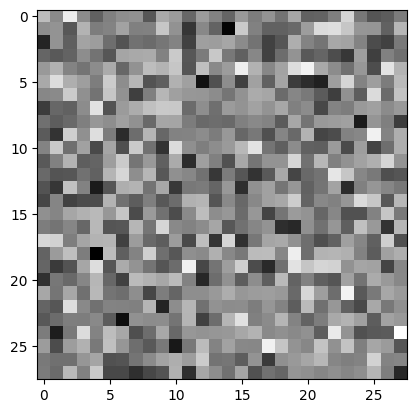

In [ ]:
generator = make_generator_model()

noise = tf.random.normal([1, 100])
generated_image = generator(noise, training=False)

plt.imshow(generated_image[0, :, :, 0], cmap='gray')

### The Discriminator

The discriminator is a CNN-based image classifier.

In [ ]:
def make_discriminator_model():

    model = tf.keras.Sequential()
    model.add(layers.Flatten(input_shape=[28,28,1]))
    model.add(layers.Dense(28 * 28 * 1))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dense(np.int64((28 * 28 * 1)/2)))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dense(1))
    model.summary()

    '''
    # Mode collapse

    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                                     input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    model.summary()
    '''

    '''
    # Convolutional network

    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                                     input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    model.summary()
    '''


    return model

Use the (as yet untrained) discriminator to classify the generated images as real or fake. The model will be trained to output positive values for real images, and negative values for fake images.

In [ ]:
discriminator = make_discriminator_model()
decision = discriminator(generated_image)
print (decision)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 784)                 │         615,440 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_8 (LeakyReLU)            │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 392)                 │         307,720 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_9 (LeakyReLU)            │ (None, 392)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 1)                   │             393 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 923,553 (3.52 MB)

 Trainable params: 923,553 (3.52 MB)

 Non-trainable params: 0 (0.00 B)

tf.Tensor([[0.02510587]], shape=(1, 1), dtype=float32)


## Define the loss and optimizers

Define loss functions and optimizers for both models.


In [ ]:
# This method returns a helper function to compute cross entropy loss
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

### Discriminator loss

This method quantifies how well the discriminator is able to distinguish real images from fakes. It compares the discriminator's predictions on real images to an array of 1s, and the discriminator's predictions on fake (generated) images to an array of 0s.

In [ ]:
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss

    return total_loss

### Generator loss
The generator's loss quantifies how well it was able to trick the discriminator. Intuitively, if the generator is performing well, the discriminator will classify the fake images as real (or 1). Here, compare the discriminators decisions on the generated images to an array of 1s.

In [ ]:
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

The discriminator and the generator optimizers are different since you will train two networks separately.

In [ ]:
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

## Define the training loop


In [ ]:
EPOCHS = 100
noise_dim = 100
num_examples_to_generate = 16

# You will reuse this seed overtime (so it's easier)
# to visualize progress in the animated GIF)
seed = tf.random.normal([num_examples_to_generate, noise_dim])

The training loop begins with generator receiving a random seed as input. That seed is used to produce an image. The discriminator is then used to classify real images (drawn from the training set) and fakes images (produced by the generator). The loss is calculated for each of these models, and the gradients are used to update the generator and discriminator.

In [ ]:
# Notice the use of `tf.function`
# This annotation causes the function to be "compiled".
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
      generated_images = generator(noise, training=True)

      real_output = discriminator(images, training=True)
      fake_output = discriminator(generated_images, training=True)

      gen_loss = generator_loss(fake_output)
      disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

In [ ]:
def train(dataset, epochs):
  for epoch in range(epochs):
    start = time.time()

    tot_gen_loss = 0
    tot_disc_loss = 0
    N = 0
    for image_batch in dataset:
      gen_loss, disc_loss = train_step(image_batch)
      tot_gen_loss += gen_loss
      tot_disc_loss += disc_loss
      N +=1

    # Produce images for the GIF as you go
    #display.clear_output(wait=True)
    generate_and_save_images(generator,
                             epoch + 1,
                             seed)
    print ('Time for epoch {} is {:.2f} sec, gen_loss = {:.2f}, disc_loss = {:.2f}'.format(epoch + 1, time.time()-start, tot_gen_loss/N, tot_disc_loss/N))

  # Generate after the final epoch
  #display.clear_output(wait=True)
  generate_and_save_images(generator,
                           epochs,
                           seed)

**Generate and save images**


In [ ]:
def generate_and_save_images(model, epoch, test_input):

  # Save the model every 10 epochs
  if (epoch + 1) % 10 == 0:
    # Notice `training` is set to False.
    # This is so all layers run in inference mode (batchnorm).
    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(4, 4))

    for i in range(predictions.shape[0]):
      plt.subplot(4, 4, i+1)
      plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
      plt.axis('off')

    plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
    plt.show()

## Train the model
Call the `train()` method defined above to train the generator and discriminator simultaneously. **Note, training GANs can be tricky. It's important that the generator and discriminator do not overpower each other (e.g., that they train at a similar rate).**

At the beginning of the training, the generated images look like random noise. As training progresses, the generated digits will look increasingly real. After about 50 epochs, they resemble MNIST digits. This may take about one minute / epoch with the default settings on Colab.

Time for epoch 1 is 7.48 sec, gen_loss = 3.08, disc_loss = 0.16
Time for epoch 2 is 2.85 sec, gen_loss = 4.95, disc_loss = 0.11
Time for epoch 3 is 2.85 sec, gen_loss = 5.68, disc_loss = 0.10
Time for epoch 4 is 2.86 sec, gen_loss = 5.27, disc_loss = 0.18
Time for epoch 5 is 2.97 sec, gen_loss = 4.06, disc_loss = 0.21
Time for epoch 6 is 2.89 sec, gen_loss = 3.35, disc_loss = 0.27
Time for epoch 7 is 2.86 sec, gen_loss = 3.01, disc_loss = 0.30
Time for epoch 8 is 2.85 sec, gen_loss = 2.58, disc_loss = 0.43


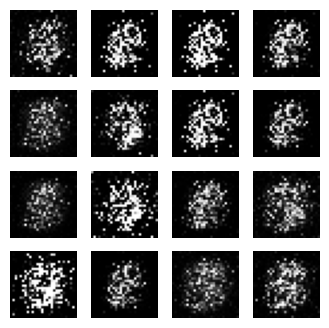

Time for epoch 9 is 3.39 sec, gen_loss = 2.26, disc_loss = 0.53
Time for epoch 10 is 2.91 sec, gen_loss = 2.17, disc_loss = 0.60
Time for epoch 11 is 2.86 sec, gen_loss = 2.10, disc_loss = 0.68
Time for epoch 12 is 2.85 sec, gen_loss = 2.08, disc_loss = 0.70
Time for epoch 13 is 2.95 sec, gen_loss = 1.85, disc_loss = 0.72
Time for epoch 14 is 2.92 sec, gen_loss = 2.07, disc_loss = 0.61
Time for epoch 15 is 2.86 sec, gen_loss = 2.11, disc_loss = 0.62
Time for epoch 16 is 2.86 sec, gen_loss = 2.42, disc_loss = 0.48
Time for epoch 17 is 2.94 sec, gen_loss = 2.26, disc_loss = 0.59
Time for epoch 18 is 2.97 sec, gen_loss = 2.23, disc_loss = 0.67


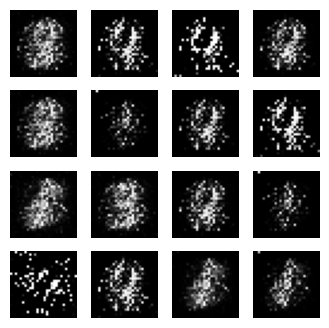

Time for epoch 19 is 3.15 sec, gen_loss = 2.26, disc_loss = 0.55
Time for epoch 20 is 2.88 sec, gen_loss = 2.13, disc_loss = 0.67
Time for epoch 21 is 2.92 sec, gen_loss = 2.14, disc_loss = 0.75
Time for epoch 22 is 2.99 sec, gen_loss = 1.91, disc_loss = 0.78
Time for epoch 23 is 2.88 sec, gen_loss = 1.85, disc_loss = 0.75
Time for epoch 24 is 2.88 sec, gen_loss = 2.05, disc_loss = 0.65
Time for epoch 25 is 2.90 sec, gen_loss = 2.08, disc_loss = 0.68
Time for epoch 26 is 3.00 sec, gen_loss = 1.91, disc_loss = 0.75
Time for epoch 27 is 2.88 sec, gen_loss = 1.79, disc_loss = 0.81
Time for epoch 28 is 5.10 sec, gen_loss = 1.99, disc_loss = 0.73


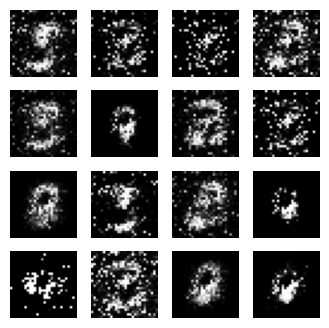

Time for epoch 29 is 3.35 sec, gen_loss = 1.94, disc_loss = 0.70
Time for epoch 30 is 2.89 sec, gen_loss = 2.08, disc_loss = 0.68
Time for epoch 31 is 2.89 sec, gen_loss = 2.13, disc_loss = 0.63
Time for epoch 32 is 2.88 sec, gen_loss = 2.38, disc_loss = 0.61
Time for epoch 33 is 3.01 sec, gen_loss = 2.37, disc_loss = 0.56
Time for epoch 34 is 2.89 sec, gen_loss = 2.21, disc_loss = 0.61
Time for epoch 35 is 2.89 sec, gen_loss = 2.39, disc_loss = 0.58
Time for epoch 36 is 2.89 sec, gen_loss = 2.51, disc_loss = 0.53
Time for epoch 37 is 2.98 sec, gen_loss = 2.25, disc_loss = 0.61
Time for epoch 38 is 2.89 sec, gen_loss = 2.30, disc_loss = 0.58


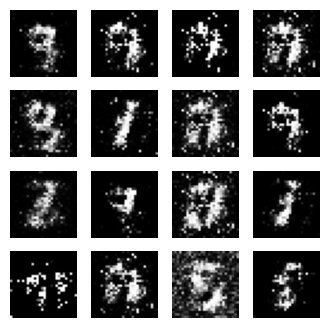

Time for epoch 39 is 3.15 sec, gen_loss = 2.20, disc_loss = 0.62
Time for epoch 40 is 2.90 sec, gen_loss = 2.42, disc_loss = 0.57
Time for epoch 41 is 3.02 sec, gen_loss = 2.38, disc_loss = 0.56
Time for epoch 42 is 2.92 sec, gen_loss = 2.38, disc_loss = 0.57
Time for epoch 43 is 2.89 sec, gen_loss = 2.25, disc_loss = 0.60
Time for epoch 44 is 2.89 sec, gen_loss = 2.47, disc_loss = 0.53
Time for epoch 45 is 3.00 sec, gen_loss = 2.37, disc_loss = 0.56
Time for epoch 46 is 2.95 sec, gen_loss = 2.38, disc_loss = 0.62
Time for epoch 47 is 2.90 sec, gen_loss = 2.54, disc_loss = 0.58
Time for epoch 48 is 2.89 sec, gen_loss = 2.55, disc_loss = 0.53


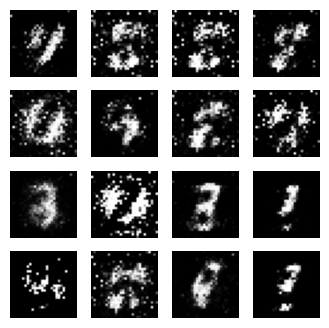

Time for epoch 49 is 3.43 sec, gen_loss = 2.57, disc_loss = 0.49
Time for epoch 50 is 2.94 sec, gen_loss = 2.53, disc_loss = 0.57
Time for epoch 51 is 2.89 sec, gen_loss = 2.39, disc_loss = 0.55
Time for epoch 52 is 2.89 sec, gen_loss = 2.65, disc_loss = 0.56
Time for epoch 53 is 2.99 sec, gen_loss = 2.53, disc_loss = 0.58
Time for epoch 54 is 2.95 sec, gen_loss = 2.60, disc_loss = 0.54
Time for epoch 55 is 2.90 sec, gen_loss = 2.52, disc_loss = 0.56
Time for epoch 56 is 2.89 sec, gen_loss = 2.62, disc_loss = 0.55
Time for epoch 57 is 2.99 sec, gen_loss = 2.54, disc_loss = 0.56
Time for epoch 58 is 2.94 sec, gen_loss = 2.54, disc_loss = 0.55


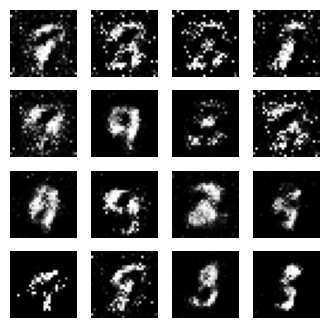

Time for epoch 59 is 3.47 sec, gen_loss = 2.41, disc_loss = 0.63
Time for epoch 60 is 2.89 sec, gen_loss = 2.43, disc_loss = 0.57
Time for epoch 61 is 2.99 sec, gen_loss = 2.53, disc_loss = 0.57
Time for epoch 62 is 2.95 sec, gen_loss = 2.51, disc_loss = 0.56
Time for epoch 63 is 2.88 sec, gen_loss = 2.52, disc_loss = 0.57
Time for epoch 64 is 2.88 sec, gen_loss = 2.46, disc_loss = 0.56
Time for epoch 65 is 2.96 sec, gen_loss = 2.30, disc_loss = 0.59
Time for epoch 66 is 2.95 sec, gen_loss = 2.44, disc_loss = 0.58
Time for epoch 67 is 5.10 sec, gen_loss = 2.50, disc_loss = 0.53
Time for epoch 68 is 2.97 sec, gen_loss = 2.54, disc_loss = 0.57


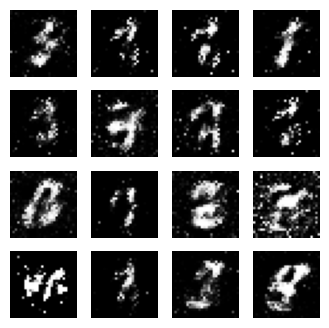

Time for epoch 69 is 3.29 sec, gen_loss = 2.58, disc_loss = 0.53
Time for epoch 70 is 2.89 sec, gen_loss = 2.47, disc_loss = 0.56
Time for epoch 71 is 2.89 sec, gen_loss = 2.50, disc_loss = 0.58
Time for epoch 72 is 2.98 sec, gen_loss = 2.59, disc_loss = 0.56
Time for epoch 73 is 3.07 sec, gen_loss = 2.47, disc_loss = 0.60
Time for epoch 74 is 2.88 sec, gen_loss = 2.43, disc_loss = 0.60
Time for epoch 75 is 2.89 sec, gen_loss = 2.45, disc_loss = 0.55
Time for epoch 76 is 2.89 sec, gen_loss = 2.43, disc_loss = 0.57
Time for epoch 77 is 3.00 sec, gen_loss = 2.48, disc_loss = 0.54
Time for epoch 78 is 2.89 sec, gen_loss = 2.48, disc_loss = 0.59


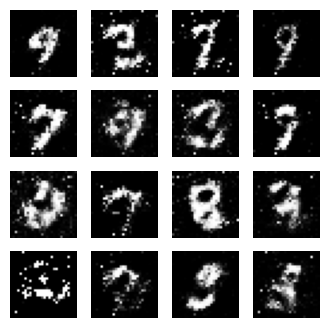

Time for epoch 79 is 3.17 sec, gen_loss = 2.43, disc_loss = 0.62
Time for epoch 80 is 2.90 sec, gen_loss = 2.43, disc_loss = 0.59
Time for epoch 81 is 3.05 sec, gen_loss = 2.53, disc_loss = 0.54
Time for epoch 82 is 2.89 sec, gen_loss = 2.43, disc_loss = 0.62
Time for epoch 83 is 2.89 sec, gen_loss = 2.40, disc_loss = 0.59
Time for epoch 84 is 2.89 sec, gen_loss = 2.39, disc_loss = 0.59
Time for epoch 85 is 3.01 sec, gen_loss = 2.38, disc_loss = 0.59
Time for epoch 86 is 2.88 sec, gen_loss = 2.43, disc_loss = 0.61
Time for epoch 87 is 2.89 sec, gen_loss = 2.45, disc_loss = 0.57
Time for epoch 88 is 2.89 sec, gen_loss = 2.26, disc_loss = 0.66


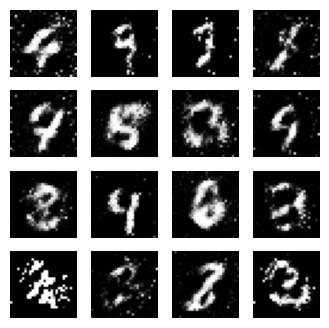

Time for epoch 89 is 3.47 sec, gen_loss = 2.28, disc_loss = 0.64
Time for epoch 90 is 2.90 sec, gen_loss = 2.21, disc_loss = 0.66
Time for epoch 91 is 2.89 sec, gen_loss = 2.20, disc_loss = 0.65
Time for epoch 92 is 2.88 sec, gen_loss = 2.30, disc_loss = 0.67
Time for epoch 93 is 2.99 sec, gen_loss = 2.30, disc_loss = 0.64
Time for epoch 94 is 2.95 sec, gen_loss = 2.22, disc_loss = 0.66
Time for epoch 95 is 2.89 sec, gen_loss = 2.33, disc_loss = 0.64
Time for epoch 96 is 2.89 sec, gen_loss = 2.20, disc_loss = 0.67
Time for epoch 97 is 2.99 sec, gen_loss = 2.17, disc_loss = 0.68
Time for epoch 98 is 2.95 sec, gen_loss = 2.20, disc_loss = 0.67


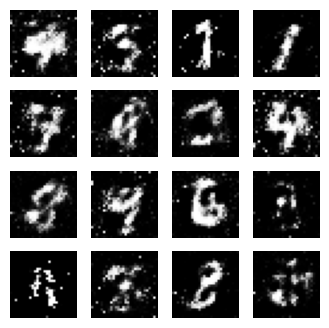

Time for epoch 99 is 3.18 sec, gen_loss = 2.18, disc_loss = 0.69
Time for epoch 100 is 2.90 sec, gen_loss = 2.11, disc_loss = 0.71


In [ ]:
train(train_dataset, EPOCHS)



---



#**Failure Modes (ways in which GANs fail)**

**Mode collapse** — i.e., learn to produce one mode
of data distribution. This happens, when discriminator performs much better than generator.

In the process of training, the generator is always trying to find the one output that seems most plausible to the discriminator.
Because of that, the discriminator’s best strategy is always to reject the output of the generator.

But if the next generation of discriminator gets stuck in a local minimum and doesn’t find its way out by getting its weights even more optimized, it’d get easy for the next generator iteration to find the most plausible output for the current discriminator.

---

How to make the above code failing? Improve discriminator by replacing the dense network by the convolutional one and remove the BatchNormalization layers from the generator.

The generator and discriminator codes leading to mode collaple are commented outin the code.




#<font color='red'> **Exercise: Please test the GAN after these modifications!**

We should get something like that, generate just one digit instead of the spectrum of different digits:

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/MachineLearning2020_1012.png' width=450px>


# **Deconvolutional GANs \(DCGAN\) \(Radford et al\.\, 2015\)**
https://arxiv.org/abs/1511.06434

Use for images – use convolutional DNN for both discriminator and generator

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/MachineLearning2020_1013.png' width=450px>



<span style="color:#03495C"> __Deconvolutional GANs \(DCGAN\)__ </span>  

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/MachineLearning2020_1014.png' width=450px>

* <span style="color:#0076A3"> __Based on LSUN data set__ </span>
  * <span style="color:#009DD9"> __10 scene categories__ </span>
  * <span style="color:#009DD9"> __20 object categories__ </span>
* <span style="color:#A9A100"> _[ArXiv ](https://arxiv.org/abs/1506.03365)_ </span>  <span style="color:#A9A100"> _[1506\.03365](https://arxiv.org/abs/1506.03365)_ </span>


<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/MachineLearning2020_1015.png' width=450px>

---

#**Generating hand\-written letters again:**

But this time we replace the dense layers in the generator and discriminator by convolutional layers (commented out in the code).






#**Generating faces**

Another DCGAN example is the code to generate new human faces from the database of celebrities photos (CELEBA - 200 000 photos) can be obtained from the Keras examples:

https://keras.io/examples/generative/dcgan_overriding_train_step/

<!---
<img src='https://i.imgur.com/h5MtQZ7l.png' width=650px>
--->


I have run this code on another server. The face image was reduced to 32x32 pixels and the number of training images reduced to 100 000 due to limitations.

* Original images:

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2023/main/images/Zrzut%20ekranu%202023-04-11%20130212.png' width=700px>

---

**Generation results:**

* 1-st epoch:

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2023/main/images/Zrzut%20ekranu%202023-04-11%20122127.png' width=700px>

* 5-th epoch:

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2023/main/images/Zrzut%20ekranu%202023-04-11%20122248.png' width=700px>

* 10-th epoch:

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2023/main/images/Zrzut%20ekranu%202023-04-11%20122717.png' width=700px>

* 15-th epoch:

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2023/main/images/Zrzut%20ekranu%202023-04-11%20122924.png' width=700px>

* 20-th epoch:

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2023/main/images/Zrzut%20ekranu%202023-04-11%20123002.png' width=700px>


* 25-th epoch:

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2023/main/images/Zrzut%20ekranu%202023-04-11%20123031.png' width=700px>


* 30-th epoch:

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2023/main/images/Zrzut%20ekranu%202023-04-11%20123100.png' width=700px>


* 50-th epoch:

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2023/main/images/Zrzut%20ekranu%202023-04-11%20173611.png' width=700px>


* 75-th epoch:

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2023/main/images/Zrzut%20ekranu%202023-04-11%20173700.png' width=700px>


* 100-th epoch:

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2023/main/images/Zrzut%20ekranu%202023-04-11%20173733.png' width=700px>



## **Generated faces are becoming more and more realistic!!!**

But:

* We need a lot of computing power (for that couple hours of GPU was needed).
* We need **HUGE** (100 000 !!!) photographs to train on.


---

#<font color='red'>**(DC)GAN guidelines:**

---

* All the pooling layers are replaced with strided convolutions in the discriminator and fractional strided convolution in the generator**<sup>*</sup>**.
* No fully-connected or pooling layers are used.
* Batchnorm used in both Generator and Discriminator
* **ReLu** or **LeakyReLu** activation is used for the generator for all the layers except the last layer which uses **tanh**
* Discriminator uses **LeakyReLu** for all the layers

**<sup>*</sup>** <font size="2">*Fractionally strided convolutions, sometimes referred to as deconvolutions, transpose images, typically from a minimized format to a larger one. Imagine an image that has been reduced to a 2x2 pixel format. To transpose the image up to a larger format, a fractionally strided convolution reconstructs the image's spatial resolution, then performs the convolution.*</font>


---

<font size="2"> ***source:** https://medium.com/analytics-vidhya/dcgan-tutorial-by-aniket-maurya-f6c137ef0053* </font>

---



#**Providing Images as Input to Generator**

* **Image Super\-Resolution**  (Ledig et al\.\, 2017\)  https://openaccess.thecvf.com/content_cvpr_2017/papers/Ledig_Photo-Realistic_Single_Image_CVPR_2017_paper.pdf

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/MachineLearning2020_1024.png' width=450px>




* **Cycle GANs** (Zhu et al\.\, 2017; arXiv:1703:10593v2 \) https://arxiv.org/abs/1703.10593v2

  Cycle GANs allow image-to-image translation given two image collections. Algorithm learns to translate an image from one collection to the other, does not require correspondence between images

  <img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/MachineLearning2020_1025.jpg' width=450px>

  <span style="color:#0076A3"> __Given two image collections:__ </span>
  * <span style="color:#009DD9"> __algorithm learns to translate an image from one collection to the other__ </span>
  * <span style="color:#009DD9"> __does not require corres\-pondence between images__ </span>

  **Photos to paintings:**
  <img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/MachineLearning2020_1026.jpg' width=450px>

  **Paintings to photos:**

  <img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/MachineLearning2020_1027.jpg' width=450px>

  A nice example of cycle GAN (converting horses to zebras) with some description can be found in keras examples: <br>
  https://keras.io/examples/generative/cyclegan/


* **Conditional GAN (CGAN)**

  A simple DCGAN doesn't let us control the appearance (e.g. class) of the samples we're generating. For instance, with a GAN that generates MNIST handwritten digits, a simple DCGAN wouldn't let us choose the class of digits we're generating. To be able to control what we generate, we need to condition the GAN output on a semantic input, such as the class of an image.

  During the training:
  * Latent variable is passed to the
generator and the discriminator.
  * The generator learns side information conditional
distributions, as it is able to
disentangle this from the overall
latent space.

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/Summary-of-the-Differences-Between-the-Conditional-GAN-Semi-Supervised-GAN-InfoGAN-and-AC-GAN-1024x423.png' width=350px>

  **Example:**
  
  Conditional GAN in keras examples:
  https://keras.io/examples/generative/conditional_gan/

  in which MNIST hand written digits are generated, but we can choose which class to generate.


#**Known problems with GANs:**

<span style="color:#03495C"> __Problems With Counting__ </span>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/MachineLearning2020_1039.png' width=450px>



<span style="color:#03495C"> __Problems With Perspective__ </span>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/MachineLearning2020_1040.png' width=450px>



<span style="color:#03495C"> __Problems With Global Structure__ </span>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/MachineLearning2020_1041.png' width=450px>





#**Applications of GAN**

<span style="color:#000000">In science \- speed up generation of simulated data – new simulated event look similar to the once already simulated/collected data\.</span>

<span style="color:#000000">Overview of GAN applications:</span>

<span style="color:#000000">[https://machinelearningmastery\.com/impressive\-applications\-of\-generative\-adversarial\-networks/](https://machinelearningmastery.com/impressive-applications-of-generative-adversarial-networks/)</span>



# <font color='green'> **Some nice examples**


#**Add colors to pictures \- DeOldify**

<span style="color:#000000">[https://github\.com/jantic/DeOldify](https://github.com/jantic/DeOldify)</span>  <span style="color:#000000"> </span>

<span style="color:#000000">An open code project\, adds color to pictures and to the movies\. You can run it by yourself on Google Colab</span>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/MachineLearning2020_1029.png' width=450px>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/MachineLearning2020_1030.png' width=450px>

Prof\. Henryk Niewodniczański

Founder of our Institute

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/MachineLearning2020_1031.png' width=450px>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/MachineLearning2020_1032.png' width=450px>

---



## **Let us play with DeOldify**

* Open the github repository of DeOldify and run the code on Google Colab https://colab.research.google.com/github/jantic/DeOldify/blob/master/ImageColorizerColabStable.ipynb

* Give this photo as an input:

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2023/main/images/tramwaj_xlarge.jpg' width=500px>

https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2023/main/images/tramwaj_xlarge.jpg

* DeOldify it:

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2023/main/images/tramwa_xlarge_colored.png' width=500px>

* Think what is wrong and why?

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2023/main/images/tramwaj_new.jpg' width=400px>


#**Make art with GAN\!\!\!**

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/MachineLearning2020_1033.png' width=450px>

<span style="color:#FFFFFF"> __Sold for a reported__ </span>  <span style="color:#FF0000"> __for $432\,500__ </span>  <span style="color:#FFFFFF"> __at an auction\!\!\!__ </span>

"Edmond de Belamy" is part of a fictitious family created by a "generative adversarial network\," of which there's ten other paintings\. "Edmond" is one of the most striking of the paintings\, and will likely become an important part of art history going forward thanks to its huge selling price\. The generator behind the painting created new portraits based on 15\,000 from the last 600 years\, taking existing art and crafting something wholly original and quite alien\.

---

#**Create a new Rembrandt painting**
based on all of his works: </span>  <span style="color:#000000">[https://www\.nextrembrandt\.com/](https://www.nextrembrandt.com/)</span>  <span style="color:#000000"> </span>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/MachineLearning2020_1034.png' width=450px>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/MachineLearning2020_1035.png' width=450px>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture9/MachineLearning2020_1036.png' width=450px>



# <font color='green'> **Make your own art**

[List of Top 10 Text-to-Image Generators](https://startuptalky.com/best-text-to-image-generator/)

* Photosonic
* Jasper.ai Art
* Dall-E
* Fotor
* Midjourney
* Nightcafe
* Canva
* Stable Diffusion
* Dreamstudio
* StarryAI



## <img src='https://tse2.mm.bing.net/th/id/OIP.bYtQsZlspQofrAQn4-gzuwAAAA?pid=ImgDet&rs=1' width=100px> **Let's play with [Starry AI](https://starryai.com/)**   


* **Generate art:**

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2023/main/images/MarcChagall_1.png' width=450px>

Marc Chagall Angel Flying Over City At Night

---

* **Generate realistic photo:**

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2023/main/images/1za91ppt.png' width=450px>

A Kraków Tram Stopping At The Railway Station

We have used this colored photo as an initial image:

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2023/main/images/tramwaj_colored.png' width=250px>

---


* let's try with another initial image (blue tramway):

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2023/main/images/tramwaj_new.jpg' width=250px>

and we get a **blue Cracow tram**:

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2023/main/images/tram_blue.webp' width=450px>









---



---



---





---

---

# <font color=green> **Stable diffusion generator**



---



---



Stable Diffusion is a deep learning, text-to-image model **released in 2022** (very new!!!) based on diffusion techniques. It is considered to be a part of the ongoing artifical intelligence boom.

Stable Diffusion, originated from a project called Latent Diffusion, developed by researchers at Ludwig Maximilian University in Munich and Heidelberg University. 4 of the original 5 authors (Robin Rombach, Andreas Blattmann, Patrick Esser and Dominik Lorenz) later joined Stability AI and released subsequent versions of Stable Diffusion.

*Source: wikipedia*


### Very nice tutorial with examples:
https://scholar.harvard.edu/binxuw/classes/machine-learning-scratch/materials/stable-diffusion-scratch

With more mathematical formalism:

https://lilianweng.github.io/posts/2021-07-11-diffusion-models/

# <font color=green> **Quick Overview of Diffusion Models**






To understand how diffusion models work, let’s first look at how they are trained, which is done in a slightly nonintuitive way.

* Begin by applying noise to an image repeatedly, which creates a “Markov chain” of images. In such a way, we are able to get some number *T* of repeatedly more noisy images from a singular original image.

* The model learns to predict the exact noise that was applied at a certain time step, and we can use its output to “denoise” the image at that time step.

* This effectively allows us to go from image T to image T-1 (backward in noise adding chain). The model is trained by giving it the image with noise applied at some time T, and the time T itself, and the output is what **noise** was applied to bring it from time T-1 to T!

* **Image generation**: once such a model is trained, we can **repeatedly apply it to random noise** to produce a new image.

<img src='https://raw.githubusercontent.com/marcinwolter/MachineLearning-KISD-2024/main/images/StableDiffusion.jpg' width=800px>

###**UNet Model**

* **UNet** architecture model is commonly used to predict the noise at each time step.
* This is a type of architecture that repeatedly applies convolutional layers, pooling layers, and skip connections to first downscale an image but increase depth (feature maps), and then transposed convolutions are used to up-sample the feature maps back to the original image dimensions (a little similar to autoencoder).

**To explain U-Net in one sentence, it would be that U-Net is like an encoder-decoder for images, but with skip connections to make sure fine details are not lost. U-Net are used often in many segmentation tasks, and in recent years have made their ways onto image generation tasks as well.**

*For more Unet info see for example:*

*https://towardsdatascience.com/understanding-u-net-61276b10f360*


<img src='https://raw.githubusercontent.com/marcinwolter/MachineLearning-KISD-2024/main/images/Unet.webp' width=800px>

U-Net was developed for the task of semantic segmentation[*].

How to apply the concept of encoder-decoder to images segmentation? We can generate a one-dimensional binary mask and train the network using cross-entropy loss. Our network consists of two parts: the encoder which extracts relevant features from images, and the decoder part which takes the extracted features and reconstructs a segmentation mask.

Because deep neural networks can “forget” certain features as it pass information through successive layers, **skip connections** can reintroduce them to make learning stronger. We can add skip connections to U-Net such that every decoder incorporate the feature map from its corresponding encoder. This is a defining feature of U-Net.

<img src='https://raw.githubusercontent.com/marcinwolter/MachineLearning-KISD-2024/main/images/segmentation.webp' width=800px>

*The task: to segment ellipses and not segment any other shapes.*



---



 *Source: https://towardsdatascience.com/understanding-u-net-61276b10f360*

 [*] Ronneberger O, Fischer P, Brox T (2015). "U-Net: Convolutional Networks for Biomedical Image Segmentation". [arXiv:1505.04597](https://arxiv.org/abs/1505.04597)

##**Text**

How to add the text factor into this?

When training our model, we not only train it to diffuse images (or, more accurately the latent space representations of these images produced by our first model), we also train it to understand the text and use to generate these images.

This is because “cross attention”, the mechanism which allows the model to selectively focus on certain text features or aspects, is built into the model itself.
Our Denoising UNet is fed the text and some random noise (both encoded), and its final output is compared to the original image. The model both learns to use the text effectively and denoise effectively at the same time.

<img src='https://upload.wikimedia.org/wikipedia/commons/f/f6/Stable_Diffusion_architecture.png' width=600px>

#<font color="green"> **Example of stable diffusion code**

Code adapted from: https://github.com/huggingface/diffusion-models-class/blob/main/unit1/01_introduction_to_diffusers.ipynb

# Introduction to 🤗 Diffusers

![diffusers_library](https://github.com/huggingface/diffusers/raw/main/docs/source/en/imgs/diffusers_library.jpg)

In this notebook, you'll train your first diffusion model to **generate images of cute butterflies 🦋.** Along the way, you'll learn about the core components of the 🤗 Diffusers library, which will provide a good foundation for the more advanced applications that we'll cover later in the course.

Let's dive in!

## What You Will Learn

In this notebook you will:

- See a powerful custom diffusion model pipeline in action (with information on how to make your own version)
- Create your own mini pipeline by:
  - Recapping the core ideas behind diffusion models
  - Loading in data from the Hub for training
  - Exploring how we add noise to this data with a scheduler
  - Creating and training the UNet model
  - Putting the pieces together into a working pipeline
- Edit and run a script for initializing longer training runs, that will handle
  - Multi-GPU training via 🤗 Accelerate
  - Experiment logging to track critical stats
  - Uploading the final model to the Hugging Face Hub

❓If you have any questions, please post them on the `#diffusion-models-class` channel on the Hugging Face Discord server. If you haven't signed up yet, you can do so here: https://huggingface.co/join/discord

## Step 1: Setup

Finally, let's import the libraries we'll be using and define a few convenience functions which we'll use later in the notebook:

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from matplotlib import pyplot as plt
from PIL import Image


def show_images(x):
    """Given a batch of images x, make a grid and convert to PIL"""
    x = x * 0.5 + 0.5  # Map from (-1, 1) back to (0, 1)
    grid = torchvision.utils.make_grid(x)
    grid_im = grid.detach().cpu().permute(1, 2, 0).clip(0, 1) * 255
    grid_im = Image.fromarray(np.array(grid_im).astype(np.uint8))
    return grid_im


def make_grid(images, size=64):
    """Given a list of PIL images, stack them together into a line for easy viewing"""
    output_im = Image.new("RGB", (size * len(images), size))
    for i, im in enumerate(images):
        output_im.paste(im.resize((size, size)), (i * size, 0))
    return output_im


# Mac users may need device = 'mps' (untested)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

OK, we're all set!

Run the following cell to install the diffusers library as well as a few other requirements:

In [ ]:
%pip install -qq -U diffusers datasets transformers accelerate ftfy pyarrow==9.0.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 873.1/873.1 kB 35.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.1/507.1 kB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 119.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.7/354.7 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.

## MVP (Minimum Viable Pipeline)

The core API of 🤗 Diffusers is divided into three main components:
1. **Pipelines**: high-level classes designed to rapidly generate samples from popular trained diffusion models in a user-friendly fashion.
2. **Models**: popular architectures for training new diffusion models, *e.g.* [UNet](https://arxiv.org/abs/1505.04597).
3. **Schedulers**: various techniques for generating images from noise during *inference* as well as to generate noisy images for *training*.

Pipelines are great for end-users, but if you're here for this course we assume you want to know what is going on under the hood!

We're training from scratch with a small data sample (1000 images only). Speaking of training, recall from the introduction to this unit that training a diffusion model looks something like this:


1.   Load in some images from the training data
2.   Add noise, in different amounts.
3.   Feed the noisy versions of the inputs into the model
4.   Evaluate how well the model does at denoising these inputs
5.   Use this information to update the model weights, and repeat

We'll explore these steps one by one in the next few sections until we have a complete training loop working, and then we'll explore how to sample from the trained model and how to package everything up into a pipeline for easy sharing. Let's begin with the data...

## Step 2: Download a training dataset

For this example, we'll use a dataset of images from the Hugging Face Hub. Specifically, [this collection of 1000 butterfly pictures](https://huggingface.co/datasets/huggan/smithsonian_butterflies_subset). This is a very small dataset, so we've also included commented out lines for a few larger options. If you'd prefer to use your own collection of images, you can also use the commented-out code example to load in pictures from a folder instead.

In [ ]:
!pip install datasets

  Using cached datasets-3.5.0-py3-none-any.whl.metadata (19 kB)
  Using cached xxhash-3.5.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (12 kB)
  Using cached multiprocess-0.70.16-py311-none-any.whl.metadata (7.2 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 14.1 MB/s eta 0:00:00
Using cached xxhash-3.5.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (194 kB)
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch

In [ ]:
import torchvision
from datasets import load_dataset
from torchvision import transforms

dataset = load_dataset("huggan/smithsonian_butterflies_subset", split="train")

# Or load images from a local folder
# dataset = load_dataset("imagefolder", data_dir="path/to/folder")

# We'll train on 32-pixel square images, but you can try larger sizes too
image_size = 32
# You can lower your batch size if you're running out of GPU memory
batch_size = 64

# Define data augmentations
preprocess = transforms.Compose(
    [
        transforms.Resize((image_size, image_size)),  # Resize
        transforms.RandomHorizontalFlip(),  # Randomly flip (data augmentation)
        transforms.ToTensor(),  # Convert to tensor (0, 1)
        transforms.Normalize([0.5], [0.5]),  # Map to (-1, 1)
    ]
)


def transform(examples):
    images = [preprocess(image.convert("RGB")) for image in examples["image"]]
    return {"images": images}


dataset.set_transform(transform)

# Create a dataloader from the dataset to serve up the transformed images in batches
train_dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, shuffle=True
)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/609 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json:   0%|          | 0.00/1.65k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/237M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

We can grab a batch of images and view some of them like so:

X shape: torch.Size([8, 3, 32, 32])


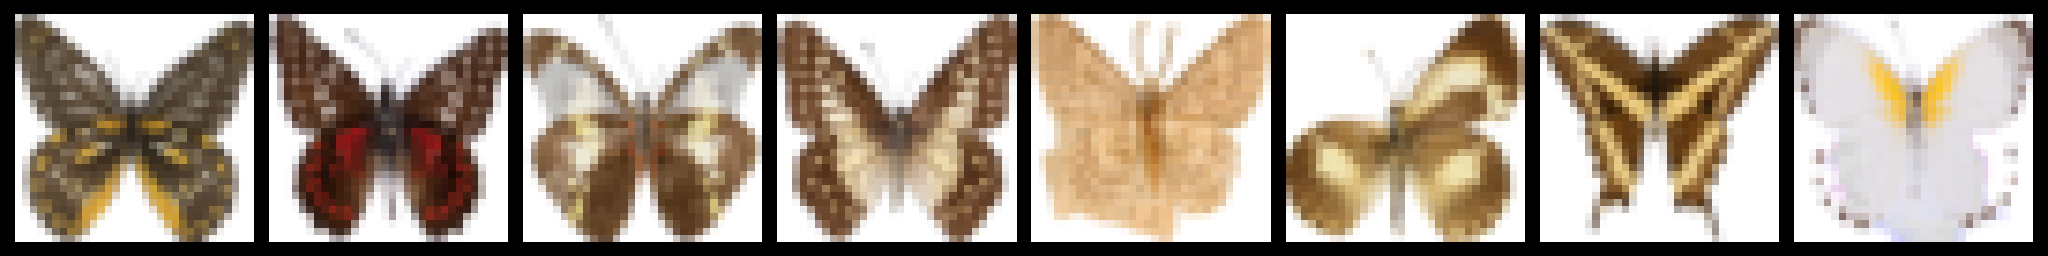

In [ ]:
xb = next(iter(train_dataloader))["images"].to(device)[:8]
print("X shape:", xb.shape)
show_images(xb).resize((8 * 256, 256), resample=Image.NEAREST)

We're sticking to a small dataset with 32 pixel images to keep training times manageable in this notebook.

## Step 3: Define the Scheduler

Our plan for training is to take these input images and add noise to them, then feed the noisy images to the model. And during inference, we will use the model predictions to iteratively remove noise. In `diffusers`,  these processes are both handled by the **scheduler**.

The noise schedule determines how much noise is added at different timesteps. Here's how we might create a scheduler using the default settings for 'DDPM' training and sampling (based on the paper ["Denoising Diffusion Probabilistic Models"](https://arxiv.org/abs/2006.11239)):

In [ ]:
from diffusers import DDPMScheduler

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)

The DDPM paper describes a corruption process that adds a small amount of noise for every 'timestep'. Given $x_{t-1}$ for some timestep, we can get the next (slightly more noisy) version $x_t$ with:<br><br>

$q(\mathbf{x}_t \vert \mathbf{x}_{t-1}) = \mathcal{N}(\mathbf{x}_t; \sqrt{1 - \beta_t} \mathbf{x}_{t-1}, \beta_t\mathbf{I}) \quad
q(\mathbf{x}_{1:T} \vert \mathbf{x}_0) = \prod^T_{t=1} q(\mathbf{x}_t \vert \mathbf{x}_{t-1})$<br><br>


That is, we take $x_{t-1}$, scale it by $\sqrt{1 - \beta_t}$ and add noise scaled by $\beta_t$. This $\beta$ is defined for every t according to some schedule, and determines how much noise is added per timestep. Now, we don't necessarily want to do this operation 500 times to get $x_{500}$ so we have another formula to get $x_t$ for any t given $x_0$: <br><br>

$\begin{aligned}
q(\mathbf{x}_t \vert \mathbf{x}_0) &= \mathcal{N}(\mathbf{x}_t; \sqrt{\bar{\alpha}_t} \mathbf{x}_0, {(1 - \bar{\alpha}_t)} \mathbf{I})
\end{aligned}$ where $\bar{\alpha}_t = \prod_{i=1}^T \alpha_i$ and $\alpha_i = 1-\beta_i$<br><br>

The maths notation always looks scary! Luckily the scheduler handles all that for us. We can plot $\sqrt{\bar{\alpha}_t}$ (labelled as `sqrt_alpha_prod`) and $\sqrt{(1 - \bar{\alpha}_t)}$ (labelled as `sqrt_one_minus_alpha_prod`) to view how the input (x) and the noise are scaled and mixed across different timesteps:

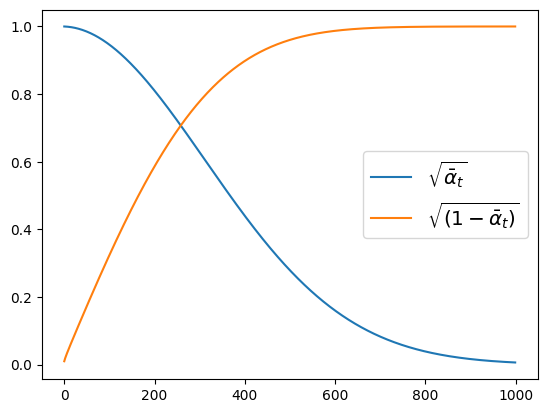

In [ ]:
plt.plot(noise_scheduler.alphas_cumprod.cpu() ** 0.5, label=r"${\sqrt{\bar{\alpha}_t}}$")
plt.plot((1 - noise_scheduler.alphas_cumprod.cpu()) ** 0.5, label=r"$\sqrt{(1 - \bar{\alpha}_t)}$")
plt.legend(fontsize="x-large");

**Exercise:** You can explore how this plot changes with different settings for beta_start, beta_end and beta_schedule by swapping in one of the commented-out options here:

In [ ]:
# One with too little noise added:
# noise_scheduler = DDPMScheduler(num_train_timesteps=1000, beta_start=0.001, beta_end=0.004)
# The 'cosine' schedule, which may be better for small image sizes:
# noise_scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule='squaredcos_cap_v2')

Whichever scheduler you've chosen, we can now use it to add noise in different amounts using the `noise_scheduler.add_noise` function like so:

Noisy X shape torch.Size([8, 3, 32, 32])


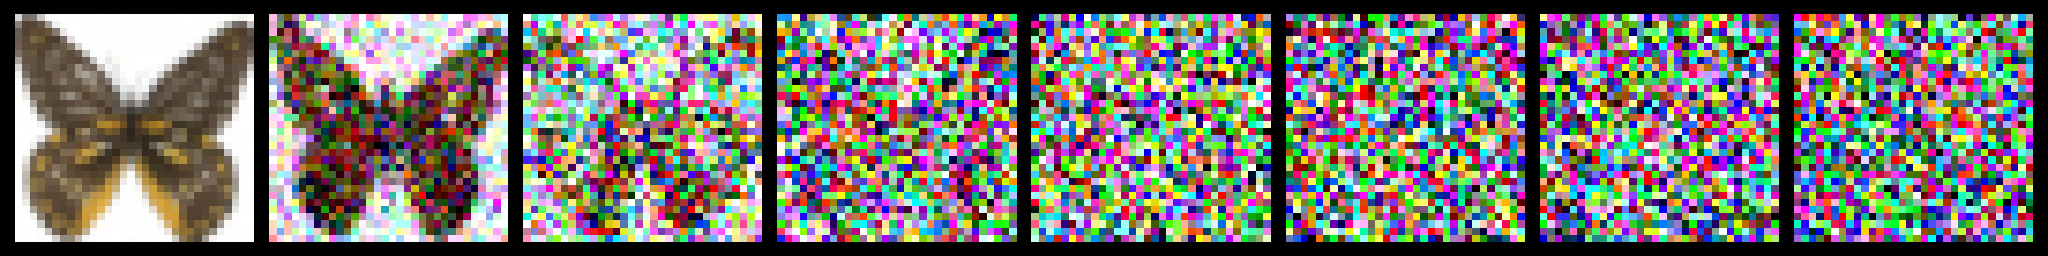

In [ ]:
timesteps = torch.linspace(0, 999, 8).long().to(device)
noise = torch.randn_like(xb)
noisy_xb = noise_scheduler.add_noise(xb, noise, timesteps)
print("Noisy X shape", noisy_xb.shape)
show_images(noisy_xb).resize((8 * 256, 256), resample=Image.NEAREST)

Again, explore the effect of using different noise schedules and parameters here. [This video](https://www.youtube.com/watch?v=fbLgFrlTnGU) does a great job explaining some of the maths above in more detail, and is a great introduction to some of these concepts.

## Step 4: Define the Model

Now we come to the core component: the model itself.

Most diffusion models use architectures that are some variant of a [U-net](https://arxiv.org/abs/1505.04597) and that's what we'll use here.

![](https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/unet-model.png)

In a nutshell:
- the model has the input image go through several blocks of ResNet layers, each of which halves the image size by 2
- then through the same number of blocks that upsample it again.
- there are skip connections linking the features on the downsample path to the corresponding layers in the upsample path.

A key feature of this model is that it predicts images of the same size as the input, which is exactly what we need here.

Diffusers provides us a handy `UNet2DModel` class which creates the desired architecture in PyTorch.

Let's create a U-net for our desired image size.
Note that `down_block_types` correspond to the downsampling blocks (green on the diagram above), and `up_block_types` are the upsampling blocks (red on the diagram):

In [ ]:
from diffusers import UNet2DModel

# Create a model
model = UNet2DModel(
    sample_size=image_size,  # the target image resolution
    in_channels=3,  # the number of input channels, 3 for RGB images
    out_channels=3,  # the number of output channels
    layers_per_block=2,  # how many ResNet layers to use per UNet block
    block_out_channels=(64, 128, 128, 256),  # More channels -> more parameters
    down_block_types=(
        "DownBlock2D",  # a regular ResNet downsampling block
        "DownBlock2D",
        "AttnDownBlock2D",  # a ResNet downsampling block with spatial self-attention
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D",  # a ResNet upsampling block with spatial self-attention
        "UpBlock2D",
        "UpBlock2D",  # a regular ResNet upsampling block
    ),
)
model.to(device);

When dealing with higher-resolution inputs you may want to use more down and up-blocks, and keep the attention layers only at the lowest resolution (bottom) layers to reduce memory usage. We'll talk later about how you might experiment to find the best settings for your use-case.

We can check that passing in a batch of data and some random timesteps produces an output the same shape as the input data:

In [ ]:
with torch.no_grad():
    model_prediction = model(noisy_xb, timesteps).sample
model_prediction.shape

torch.Size([8, 3, 32, 32])

In the next section we'll see how to train this model.

## Step 5: Create a Training Loop

Time to train! Below is a typical optimization loop in PyTorch, where we run through the data batch by batch and update the parameters of our model each step using an optimizer - in this case the AdamW optimizer with a learning rate of 0.0004.

For each batch of data, we
- Sample some random timesteps
- Noise the data accordingly
- Feed the noisy data through the model
- Compare the model predictions with the target (i.e. the noise in this case) using mean squared error as our loss function
- Update the model parameters via `loss.backward()` and `optimizer.step()`

During this process we also log the losses over time for later plotting.

NB: This code takes nearly 10 minutes to run - feel free to skip these two cells and use the pretrained model if you are in a hurry. Alternatively, you can explore how reducing the number of channels in each layer via the model definition above can speed things up.

The [official diffusers training example](https://colab.research.google.com/github/huggingface/notebooks/blob/main/diffusers/training_example.ipynb) trains a larger model on this dataset at higher resolution, and is a good reference for what a less minimal training loop looks like:

In [ ]:
from diffusers import DDPMPipeline

In [ ]:
# Set the noise scheduler
noise_scheduler = DDPMScheduler(
    num_train_timesteps=1000, beta_schedule="squaredcos_cap_v2"
)

# Training loop
optimizer = torch.optim.AdamW(model.parameters(), lr=4e-4)

losses = []

for epoch in range(30):
    for step, batch in enumerate(train_dataloader):
        clean_images = batch["images"].to(device)
        # Sample noise to add to the images
        noise = torch.randn(clean_images.shape).to(clean_images.device)
        bs = clean_images.shape[0]

        # Sample a random timestep for each image
        timesteps = torch.randint(
            0, noise_scheduler.num_train_timesteps, (bs,), device=clean_images.device
        ).long()

        # Add noise to the clean images according to the noise magnitude at each timestep
        noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

        # Get the model prediction
        noise_pred = model(noisy_images, timesteps, return_dict=False)[0]

        # Calculate the loss
        loss = F.mse_loss(noise_pred, noise)
        loss.backward(loss)
        losses.append(loss.item())

        # Update the model parameters with the optimizer
        optimizer.step()
        optimizer.zero_grad()

    if (epoch + 1) % 1 == 0:
        loss_last_epoch = sum(losses[-len(train_dataloader) :]) / len(train_dataloader)
        print(f"Epoch:{epoch+1}, loss: {loss_last_epoch}")

    #if (epoch + 1) % 1 == 0:
    #    image_pipe = DDPMPipeline(unet=model, scheduler=noise_scheduler)
    #    pipeline_output = image_pipe()
    #    show_images(pipeline_output.images[0]).resize((256, 256), resample=Image.NEAREST)

/usr/local/lib/python3.11/dist-packages/diffusers/configuration_utils.py:140: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


Epoch:1, loss: 0.4648573584854603
Epoch:2, loss: 0.2115643359720707
Epoch:3, loss: 0.17141147889196873
Epoch:4, loss: 0.16129550244659185
Epoch:5, loss: 0.15463013388216496
Epoch:6, loss: 0.15207381919026375
Epoch:7, loss: 0.1401985133998096
Epoch:8, loss: 0.13234234787523746
Epoch:9, loss: 0.1338849775493145
Epoch:10, loss: 0.1295749507844448
Epoch:11, loss: 0.11279766075313091
Epoch:12, loss: 0.11179156927391887
Epoch:13, loss: 0.1078862464055419
Epoch:14, loss: 0.1039194418117404
Epoch:15, loss: 0.10529119847342372
Epoch:16, loss: 0.10251267673447728
Epoch:17, loss: 0.10293256537988782
Epoch:18, loss: 0.08440698124468327
Epoch:19, loss: 0.09404476126655936
Epoch:20, loss: 0.09391861222684383
Epoch:21, loss: 0.10094180167652667
Epoch:22, loss: 0.08666653605177999
Epoch:23, loss: 0.09050257690250874
Epoch:24, loss: 0.08218709891662002
Epoch:25, loss: 0.08131336886435747
Epoch:26, loss: 0.08777851285412908
Epoch:27, loss: 0.08150787325575948
Epoch:28, loss: 0.07904640771448612
Epoch:29

Plotting the loss, we see that the model rapidly improves initially and then continues to get better at a slower rate (which is more obvious if we use a log scale as shown on the right):

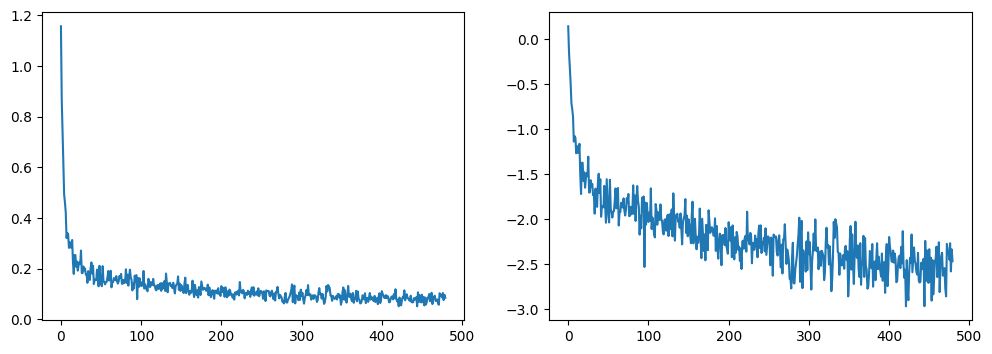

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(losses)
axs[1].plot(np.log(losses))
plt.show()

As an alternative to running the training code above, you can use the model from the pipeline like so:

In [ ]:
# Uncomment to instead load the model I trained earlier:
# model = butterfly_pipeline.unet

## Step 6: Generate Images

How do we get images with this model?

### Option 1: Creating a pipeline:

In [ ]:
from diffusers import DDPMPipeline

image_pipe = DDPMPipeline(unet=model, scheduler=noise_scheduler)

  0%|          | 0/1000 [00:00<?, ?it/s]

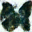

In [ ]:
pipeline_output = image_pipe()
pipeline_output.images[0]

We can save a pipeline to a local folder like so:

In [ ]:
image_pipe.save_pretrained("my_pipeline")

Inspecting the folder contents:

In [ ]:
!ls my_pipeline/

model_index.json  scheduler  unet


The `scheduler` and `unet` subfolders contain everything needed to re-create those components. For example, inside the `unet` folder you'll find the model weights (`diffusion_pytorch_model.bin`) alongside a config file which specifies the UNet architecture.

In [ ]:
!ls my_pipeline/unet/

config.json  diffusion_pytorch_model.safetensors


Together, these files contain everything needed to recreate the pipeline. You can manually upload them to the hub to share the pipeline with others, or check out the code to do this via the API in the next section.

### Option 2: Writing a Sampling Loop

If you inspect the forward method of the pipeline you'll be able to see what is happening when we run `image_pipe()`:

In [ ]:
# ??image_pipe.forward

We begin with random noise, and run through the scheduler timesteps from most to least noisy, removing a small amount of noise each step based on the model prediction:

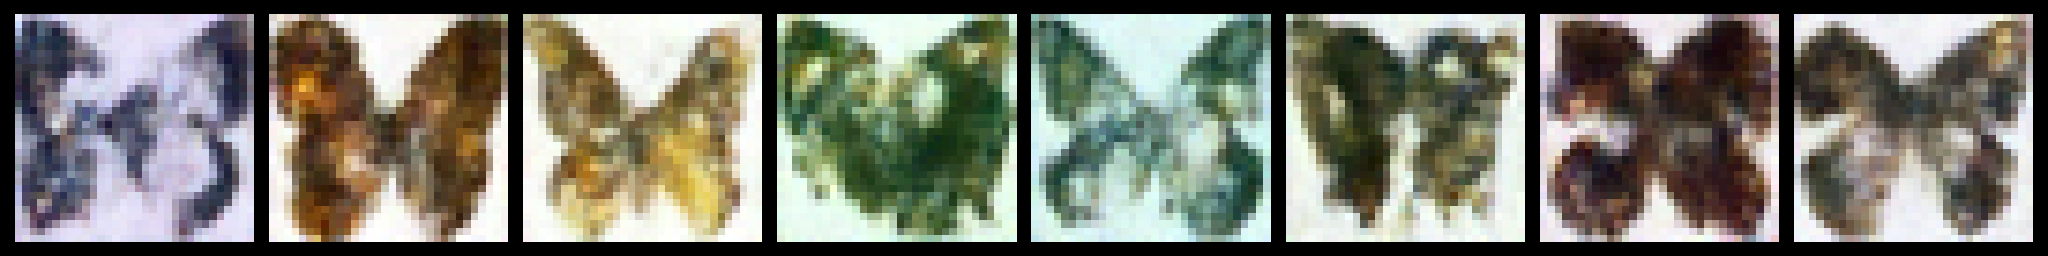

In [ ]:
# Random starting point (8 random images):
sample = torch.randn(8, 3, 32, 32).to(device)

for i, t in enumerate(noise_scheduler.timesteps):

    # Get model pred
    with torch.no_grad():
        residual = model(sample, t).sample

    # Update sample with step
    sample = noise_scheduler.step(residual, t, sample).prev_sample

show_images(sample).resize((8 * 256, 256), resample=Image.NEAREST)



---



---



---



# **Faces generation**

The same code (updated to generate 128x128 images) used to generate faces:

<img src='https://raw.githubusercontent.com/marcinwolter/MachineLearning-KISD-2024/main/images/original.png' width=800px>

*Original photos*

<img src='https://raw.githubusercontent.com/marcinwolter/MachineLearning-KISD-2024/main/images/generated.png' width=800px>

*Generated photos*

Code: https://github.com/marcinwolter/MachineLearning-KISD-2025/blob/main/01_intro.nbconvert.ipynb

Time: about 12 h.

# <mark> **Exercise**

- <mark> write your own autoencoder to finding outlers or doing any other interesting task
- <mark> it could be your project!!!

#<font color='green'> **Summary:**

* **We have learned about new methods:**

  * Deep Neural Networks
  * Data augmentation, knowledge transfer
  * Hyperparameter optimization
  * Transfer learning
  * Reinforcement learning
  * Generative Adversary Networks GAN
  * Autoencoders
  * Stable diffusion generators

* **There are many other Machine Learning techniques like:**
  * Bayesian Neural Networks and Mixture Density Networks MDN returning the probability distribution,
  * Language processing networks (small chatGPT or google translators),
  * recurent networks with memory,
  * and many, many others...

* <mark> **Please prepare your projects!!!**  

# **Next and last lecture:**


*   Generative adversarial network, GAN - another method to generate images or data
*  Reinforcement learning - how to train a robot in the natural environment?





---

---



---


# **Auto-clean notebook**



In [ ]:
# Run this in the last cell of your Colab notebook
from IPython.display import Javascript

Javascript('''
  let metadata = JSON.parse(JSON.stringify(IPython.notebook.metadata));
  if (metadata.hasOwnProperty('widgets')) {
    delete metadata['widgets'];
    IPython.notebook.metadata = metadata;
  }
''')

<IPython.core.display.Javascript object>